In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from lib import resize_img

In [5]:
def notebook_imshow(img):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

In [6]:
image = cv2.imread("../imgs/Capture4.PNG")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

resized_image = resize_img(gray)
print('img shape: ', resized_image.shape)

img shape:  (418, 1000)


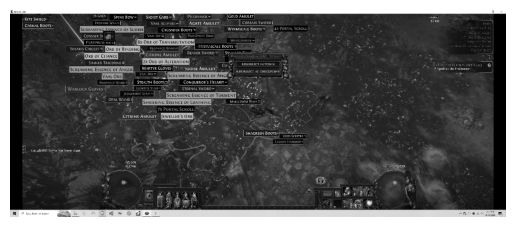

In [7]:
notebook_imshow(resized_image)

In [8]:
resized_image[50,:100]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, 57, 30, 27, 30, 32, 31, 29, 30, 30,
       28, 29, 29, 29, 28, 30, 48, 34, 47, 30, 32, 38, 30, 31, 30, 30, 31,
       30, 30, 30, 31, 31, 33, 36, 39, 42, 41, 41, 32, 28, 29, 28, 27, 27,
       28, 30, 40, 32, 32, 34, 38, 36, 42, 40, 33, 35, 39, 40, 51, 45, 39,
       46, 46, 40, 37, 38, 38, 35, 41, 39, 43, 46, 44, 45, 43, 41],
      dtype=uint8)

In [9]:
# find all subarrays with identical elements in the horizontal direction
# first, for every row, compare ith & ith+1 pixels
horizontal_diff = resized_image[:, :-1] != resized_image[:, 1:]
# append an offset column (all valued 1) at the start & end of the diff array
offset = np.ones(horizontal_diff.shape[0])
horizontal_diff = np.column_stack((offset, horizontal_diff, offset))
horizontal_diff[50, :100]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [10]:
# find non zero indices in each row
# this could also viewed as finding the start index of all subarrays that have the same elements
# thanks to the offset column ealier, we won't miss the first subarray
hline_start = [np.flatnonzero(row) for row in horizontal_diff]
hline_start[50][:100]

array([  0,  25,  26,  27,  28,  29,  30,  31,  32,  34,  35,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  50,  51,  54,  56,
        57,  58,  59,  60,  62,  63,  64,  65,  66,  68,  69,  70,  71,
        73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
        87,  88,  89,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 113, 114,
       117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139])

In [11]:
# find length of the subarrays by subtracting the start index of the next array to the it's previous array
hline_length = [row[1:] - row[:-1] for row in hline_start]
hline_length[50][:100]

array([25,  1,  1,  1,  1,  1,  1,  1,  2,  1,  3,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  2,  1,  3,  2,  1,  1,  1,  1,  2,  1,  1,  1,  1,
        2,  1,  1,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        2,  1,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  2,  1,  1,  1,  1,  1,  1,  3,  1,  2,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [12]:
MINIMUM_CURRENCY_BOX_WIDTH = 10
MAXIMUM_CURRENCY_BOX_WIDTH = 100
# Raises ValueError if we use MAXIMUM_CURRENCY_BOX_WIDTH > length > MINIMUM_CURRENCY_BOX_WIDTH 
# because 'and' forces boolean evaluation of the entire array
valid_hline_indices = [np.where((MAXIMUM_CURRENCY_BOX_WIDTH > line) & (line > MINIMUM_CURRENCY_BOX_WIDTH)) for line in hline_length]
valid_hline_indices[50]

(array([  0, 109, 777]),)

In [13]:
# next, find all subarrays with identical elements in the vertical direction
vertical_diff = resized_image[1:, :] != resized_image[:-1, :]
resized_image[:, 50][:100]

array([255, 255, 255, 255, 255, 255, 255, 255,  79,  33,  30,  27,  31,
        23,  23,  24, 197,  41,  24, 220, 237,  68,  23,  23,  23,  63,
        23,  23,  23,  23,  24,  24,  24,  70, 228,  24,  25,  26, 161,
        32,  27,  27,  30,  57,  30,  31,  96,  34,  31,  30,  31,  31,
        30,  31,  35,  31,  31,  32,  45,  31,  31,  31,  30,  36,  55,
        37,  39,  38,  30,  41,  43,  40,  33,  35,  35,  32,  26,  28,
        32,  35,  33,  32,  28,  27,  29,  31,  33,  33,  34,  34,  30,
        44,  34,  31,  37,  35,  38,  33,  36,  33], dtype=uint8)

In [14]:
vertical_diff[:, 50][:100]

array([False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True, False,
       False, False,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True, False,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [15]:
offset = np.ones(vertical_diff.shape[1])
vertical_diff = np.vstack((offset, vertical_diff, offset))
vertical_diff.shape

(419, 1000)

In [16]:
vertical_diff[:, 50][:100]

array([1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [17]:
vline_start = [np.flatnonzero(c) for c in vertical_diff.T]
vline_start[50][:100]

array([  0,   8,   9,  10,  11,  12,  13,  15,  16,  17,  18,  19,  20,
        21,  22,  25,  26,  30,  33,  34,  35,  36,  37,  38,  39,  40,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  52,  53,  54,  55,
        57,  58,  59,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,
        72,  73,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
        86,  88,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122])

In [18]:
vline_length = [c[1:] - c[:-1] for c in vline_start]
vline_length[50][:100]

array([8, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1, 4, 3, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [29]:
MINIMUM_CURRENCY_BOX_HEIGHT = 5
MAXIMUM_CURRENCY_BOX_HEIGHT = 50
# Raises ValueError if we use MAXIMUM_CURRENCY_BOX_WIDTH > length > MINIMUM_CURRENCY_BOX_WIDTH 
# because 'and' forces boolean evaluation of the entire array
valid_vline_indices = [np.where((MAXIMUM_CURRENCY_BOX_HEIGHT > line) & (line > MINIMUM_CURRENCY_BOX_HEIGHT)) for line in vline_length]
len(valid_vline_indices)

1000

In [30]:
# iterates over all elements in `valid hlines`, check whether it's in the same indices with a vertical one
# if it does, use ocr software to extract text in the box
for i, line in enumerate(valid_hline_indices):
    for j in line[0]:
        if i in valid_vline_indices[j][0]:
            print(f"Found a box at row {i}, column {j}")
            # Here you would typically extract the box and run OCR on it
            # For example:
            # box = resized_image[i:i+hline_length[i][j], j:j+vline_length[j][i]]
            # text = ocr_function(box)

        

Found a box at row 33, column 152
Found a box at row 115, column 114
Found a box at row 148, column 795
Found a box at row 173, column 809
